<a href="https://colab.research.google.com/github/Hosny100/-/blob/main/CNN_LSTM_HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 CNN-LSTM for Human Activity Recognition (HAR)

**Dataset:** UCI HAR Dataset (Smartphone Sensor Data)  
**Model:** CNN layers for spatial feature extraction → LSTM layers for temporal modeling  
**Task:** Classify 6 human activities: Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying

---

## 📦 Step 1: Install & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, LSTM, Dense, Dropout,
    BatchNormalization, Flatten, Input, TimeDistributed
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 Step 2: Download & Load UCI HAR Dataset

In [2]:
# Download the dataset
DATASET_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "UCI_HAR_Dataset.zip"
EXTRACT_PATH = "."

if not os.path.exists("UCI HAR Dataset"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    os.remove(ZIP_PATH)
    print("✅ Dataset ready!")
else:
    print("✅ Dataset already exists.")

Extracting...
✅ Dataset ready!


In [3]:
# Load raw inertial signals (9 channels: body_acc x/y/z, body_gyro x/y/z, total_acc x/y/z)

def load_signals(subset):
    """Load the 9 raw signal files for train or test subset."""
    signal_types = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    signals = []
    for signal in signal_types:
        path = f"UCI HAR Dataset/{subset}/Inertial Signals/{signal}_{subset}.txt"
        data = pd.read_csv(path, delim_whitespace=True, header=None).values
        signals.append(data)
    # Shape: (samples, timesteps, channels)
    return np.transpose(np.array(signals), (1, 2, 0))

def load_labels(subset):
    path = f"UCI HAR Dataset/{subset}/y_{subset}.txt"
    return pd.read_csv(path, header=None).values.flatten() - 1  # 0-indexed

# Load train and test sets
X_train = load_signals('train')
X_test  = load_signals('test')
y_train = load_labels('train')
y_test  = load_labels('test')

print(f"X_train shape: {X_train.shape}  → (samples, timesteps=128, channels=9)")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

/tmp/ipykernel_5916/3556165548.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None).values
/tmp/ipykernel_5916/3556165548.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None).values
/tmp/ipykernel_5916/3556165548.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None).values
/tmp/ipykernel_5916/3556165548.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path, delim_whitespace=True, header=None).values


X_train shape: (7352, 128, 9)  → (samples, timesteps=128, channels=9)
X_test shape:  (2947, 128, 9)
y_train shape: (7352,)
y_test shape:  (2947,)


## 🔍 Step 3: Exploratory Data Analysis

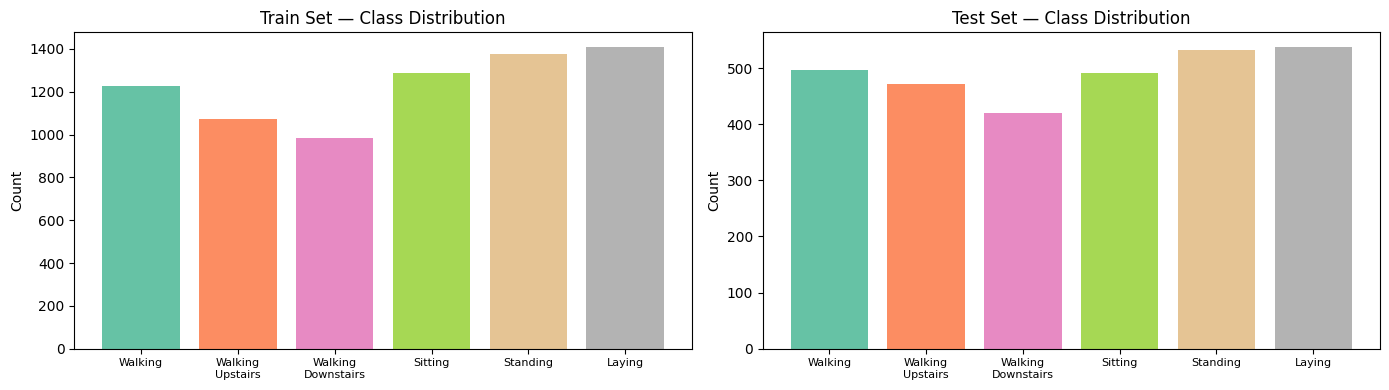

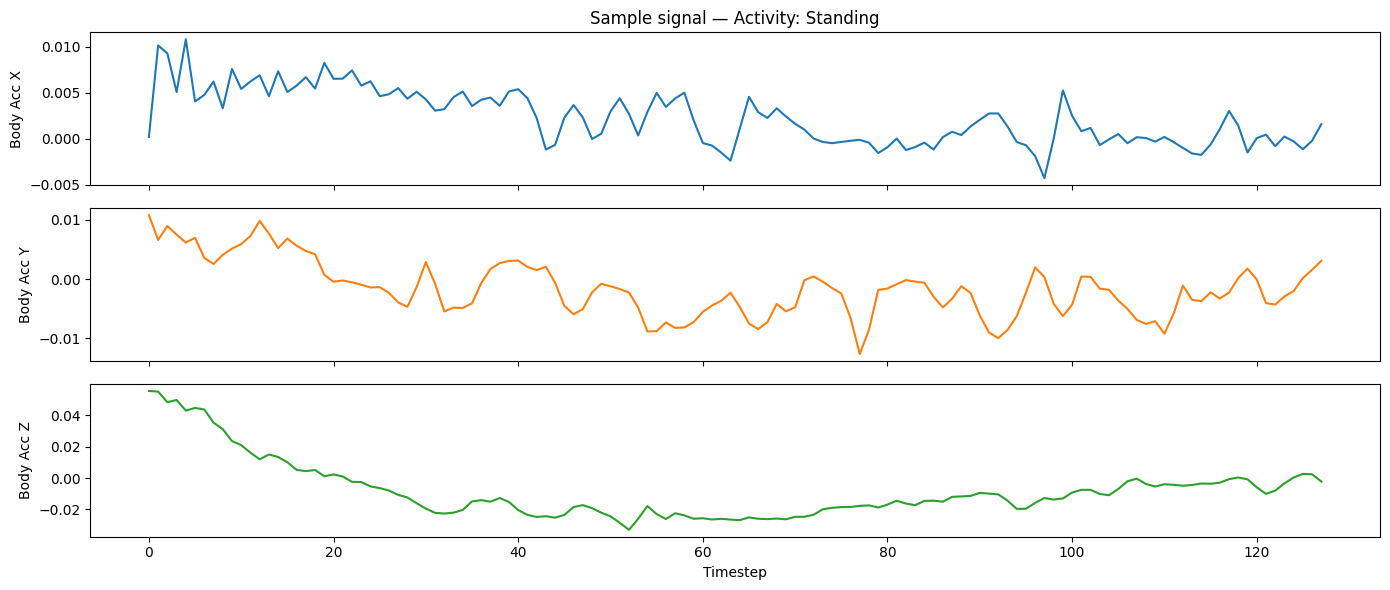

In [4]:
ACTIVITY_LABELS = [
    'Walking', 'Walking\nUpstairs', 'Walking\nDownstairs',
    'Sitting', 'Standing', 'Laying'
]

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (y, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    unique, counts = np.unique(y, return_counts=True)
    ax.bar(ACTIVITY_LABELS, counts, color=plt.cm.Set2(np.linspace(0, 1, 6)))
    ax.set_title(f'{title} Set — Class Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

# Plot a sample signal
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
channel_names = ['Body Acc X', 'Body Acc Y', 'Body Acc Z']
sample_idx = 0
for i, ax in enumerate(axes):
    ax.plot(X_train[sample_idx, :, i], color=f'C{i}')
    ax.set_ylabel(channel_names[i])
axes[0].set_title(f'Sample signal — Activity: {ACTIVITY_LABELS[y_train[sample_idx]]}')
axes[-1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

## ⚙️ Step 4: Preprocessing

In [5]:
NUM_CLASSES = 6

# Normalize each channel to [-1, 1] using train statistics
X_mean = X_train.mean(axis=(0, 1), keepdims=True)
X_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"Normalized X_train: {X_train_norm.shape}, mean≈{X_train_norm.mean():.4f}, std≈{X_train_norm.std():.4f}")
print(f"y_train_cat: {y_train_cat.shape}")

Normalized X_train: (7352, 128, 9), mean≈-0.0000, std≈1.0000
y_train_cat: (7352, 6)


## 🏗️ Step 5: Build the CNN-LSTM Model

**Architecture:**
```
Input (128, 9)
  ↓
[Conv1D → BN → ReLU] × 2   ← local pattern extraction
  ↓ MaxPool
[Conv1D → BN → ReLU]        ← higher-level features
  ↓ MaxPool
LSTM(128) → Dropout         ← temporal dependencies
LSTM(64)  → Dropout
Dense(64) → Dense(6, softmax)
```

In [6]:
def build_cnn_lstm(input_shape=(128, 9), num_classes=6):
    model = Sequential([
        # ── CNN Block 1 ──────────────────────────────
        Conv1D(filters=64, kernel_size=3, padding='same', activation='relu',
               input_shape=input_shape),
        BatchNormalization(),
        Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── CNN Block 2 ──────────────────────────────
        Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # ── LSTM Block ───────────────────────────────
        LSTM(128, return_sequences=True),
        Dropout(0.4),
        LSTM(64, return_sequences=False),
        Dropout(0.4),

        # ── Classifier ───────────────────────────────
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='CNN_LSTM_HAR')
    return model

model = build_cnn_lstm()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_LSTM_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 128, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,206 (1.05 MB)

 Trainable params: 274,438 (1.05 MB)

 Non-trainable params: 768 (3.00 KB)

## 🚀 Step 6: Compile & Train

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

BATCH_SIZE = 64
EPOCHS = 50

history = model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8382 - loss: 0.4782 - val_accuracy: 0.8631 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9462 - loss: 0.1605 - val_accuracy: 0.8903 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9502 - loss: 0.1293 - val_accuracy: 0.8849 - val_loss: 0.2801 - learning_rate: 0.0010
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9531 - loss: 0.1044 - val_accuracy: 0.8812 - val_loss: 0.4621 - learning_rate: 0.0010
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9560 - loss: 0.0989 - val_accuracy: 0.8658 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9566 - loss: 0.0993 - val_accuracy: 0.8876 - val_loss: 0.3304 - learning_rate: 0.0010
Epoch 7/50
95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9571 - loss: 0.1030
Epoch 7:

## 📈 Step 7: Training Curves

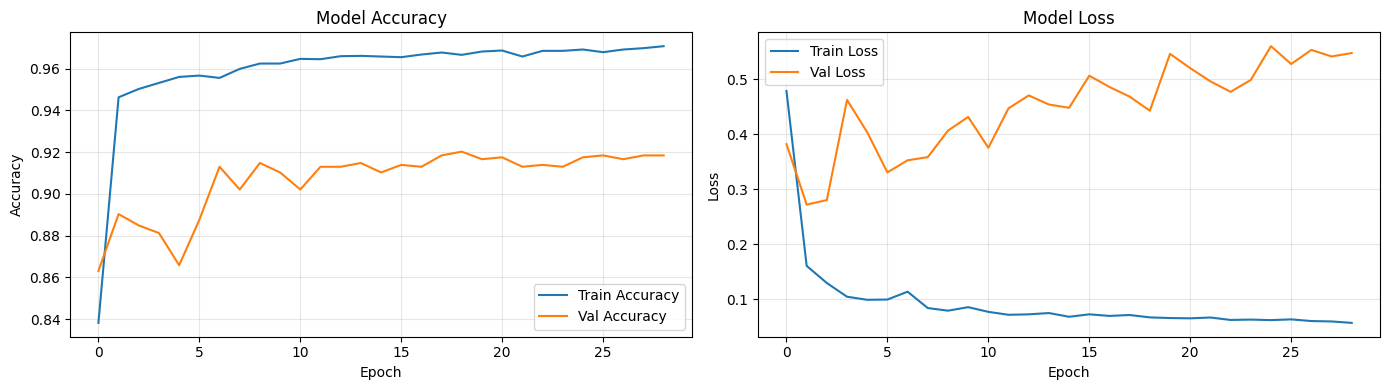

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 Step 8: Evaluation on Test Set

In [9]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*40}")


  Test Accuracy : 93.21%
  Test Loss     : 0.3512



Classification Report:
              precision    recall  f1-score   support

     Walking       0.97      1.00      0.99       496
     Walk Up       1.00      0.95      0.97       471
   Walk Down       0.95      0.98      0.96       420
     Sitting       0.82      0.85      0.83       491
    Standing       0.86      0.83      0.84       532
      Laying       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



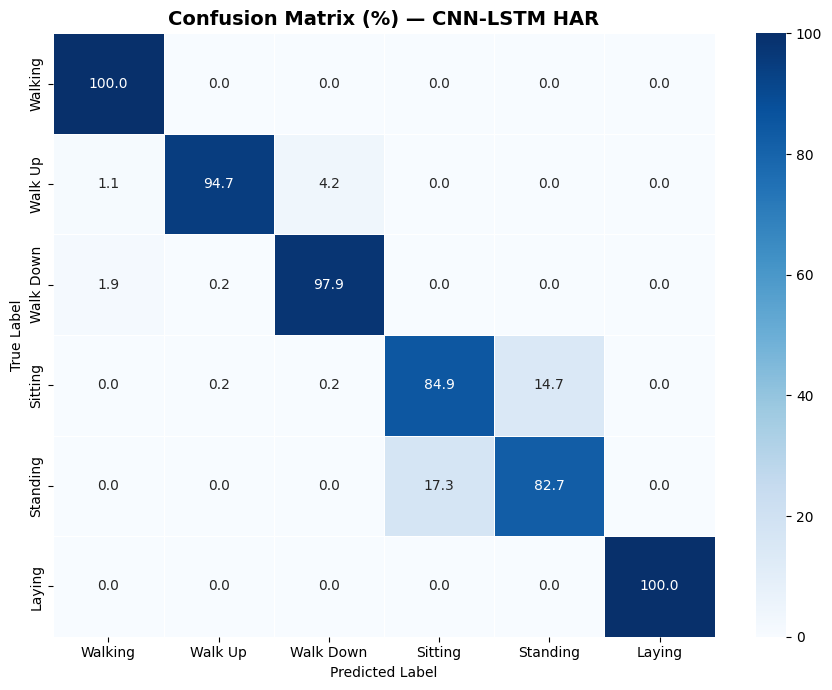

In [10]:
# Predictions
y_pred_probs = model.predict(X_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
activity_names = ['Walking', 'Walk Up', 'Walk Down', 'Sitting', 'Standing', 'Laying']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=activity_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_pct,
    annot=True, fmt='.1f', cmap='Blues',
    xticklabels=activity_names,
    yticklabels=activity_names,
    linewidths=0.5
)
plt.title('Confusion Matrix (%) — CNN-LSTM HAR', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 💾 Step 9: Save the Model

In [11]:
model.save('cnn_lstm_har_model.h5')
print("✅ Model saved as 'cnn_lstm_har_model.h5'")

# Optional: Download to local machine (Colab only)
try:
    from google.colab import files
    files.download('cnn_lstm_har_model.h5')
except ImportError:
    print("(Not running in Colab — skip download)")

✅ Model saved as 'cnn_lstm_har_model.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔮 Step 10: Predict on a Single Sample

In [12]:
# Pick a random test sample
idx = np.random.randint(0, len(X_test_norm))
sample = X_test_norm[idx:idx+1]   # shape (1, 128, 9)
true_label = y_test[idx]

probs = model.predict(sample, verbose=0)[0]
pred_label = np.argmax(probs)

print(f"\nSample index : {idx}")
print(f"True Activity : {activity_names[true_label]}")
print(f"Predicted     : {activity_names[pred_label]}  ({'✅ Correct' if pred_label == true_label else '❌ Wrong'})")
print("\nProbabilities per class:")
for name, p in zip(activity_names, probs):
    bar = '█' * int(p * 40)
    print(f"  {name:<14} {p*100:5.1f}%  {bar}")


Sample index : 841
True Activity : Walking
Predicted     : Walking  (✅ Correct)

Probabilities per class:
  Walking        100.0%  ███████████████████████████████████████
  Walk Up          0.0%  
  Walk Down        0.0%  
  Sitting          0.0%  
  Standing         0.0%  
  Laying           0.0%  


---
## ✅ Summary

| Component | Details |
|-----------|--------|
| **Dataset** | UCI HAR — 7352 train / 2947 test samples |
| **Input** | 128 timesteps × 9 sensor channels |
| **CNN** | 2 blocks (Conv1D + BN + MaxPool) for spatial features |
| **LSTM** | 2 stacked layers for temporal dependencies |
| **Output** | 6 activity classes (softmax) |
| **Expected Accuracy** | ~93–96% on test set |

### 💡 Ideas to Improve Further
- Use **Attention mechanism** after LSTM
- Try **Bidirectional LSTM**
- Experiment with **data augmentation** (jittering, scaling)
- Use **transfer learning** from a pretrained time-series model
- Compare with pure **Transformer** architecture